# ADM 2026 — EDA: Cross-Geo Product Matching

Exploring the GLAMI dataset before building any models.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Adjust if your notebook is not in notebooks/
DATA_DIR = "../data/raw"

## 1. Load the data

In [7]:
train = pd.read_csv(f"{DATA_DIR}/items_train.csv")
phase1 = pd.read_csv(f"{DATA_DIR}/items_phase_1.csv")
task1 = pd.read_csv(f"{DATA_DIR}/task_1.csv")

print(f"Train:  {train.shape}")
print(f"Phase1: {phase1.shape}")
print(f"Task1:  {task1.shape}")

print(f"Train columns' names: {train.columns.tolist()}")

Train:  (928234, 9)
Phase1: (199835, 8)
Task1:  (15000, 5)
Train columns' names: ['itemId', 'price', 'colorTagIdsString', 'departmentIds', 'brandEditionTagId', 'title', 'description', 'geo', 'label']


In [8]:
train.head()

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo,label
0,692210,148.0,"230,232",['11'],NaN,Раница Rains 14480 Черен,NaN,bg,41599
1,943360,148.0,"230,232",['11'],NaN,Раница Rains,Rains Раница 14480 Черен,bg,41599
2,447879,179.9,230,['1'],NaN,Раница Rains Trail Cord Rolltop Backpack W3 в ...,Раница от колекция Rains. Моделът е направен о...,bg,41599
3,1169543,179.9,230,"['1', '11']",NaN,Раница Rains Trail Cord Rolltop Backpack W3 в ...,- Непромокаем модел.\n- Повишена водоустойчиво...,bg,41599
4,671883,1910.0,"230,232",['11'],NaN,Batoh Rains,Rains Batoh 14480 Černá,cz,41599


In [9]:
train.dtypes

itemId                 int64
price                float64
colorTagIdsString        str
departmentIds            str
brandEditionTagId        str
title                    str
description              str
geo                      str
label                  int64
dtype: object

In [10]:
train.isnull().sum()

itemId                    0
price                     0
colorTagIdsString     27834
departmentIds             0
brandEditionTagId    925518
title                     0
description           35473
geo                       0
label                     0
dtype: int64

In [11]:
# Check what the columns actually look like
train.iloc[0]

itemId                                 692210
price                                   148.0
colorTagIdsString                     230,232
departmentIds                          ['11']
brandEditionTagId                         NaN
title                Раница Rains 14480 Черен
description                               NaN
geo                                        bg
label                                   41599
Name: 0, dtype: object

## 2. Label distribution (train set)

In [12]:
label_counts = train['label'].value_counts()
print(f"Unique labels: {label_counts.shape[0]}")
print(f"\nItems per label:")
print(label_counts.describe())

Unique labels: 152370

Items per label:
count    152370.000000
mean          6.091973
std           6.464104
min           1.000000
25%           2.000000
50%           2.000000
75%           8.000000
max          80.000000
Name: count, dtype: float64


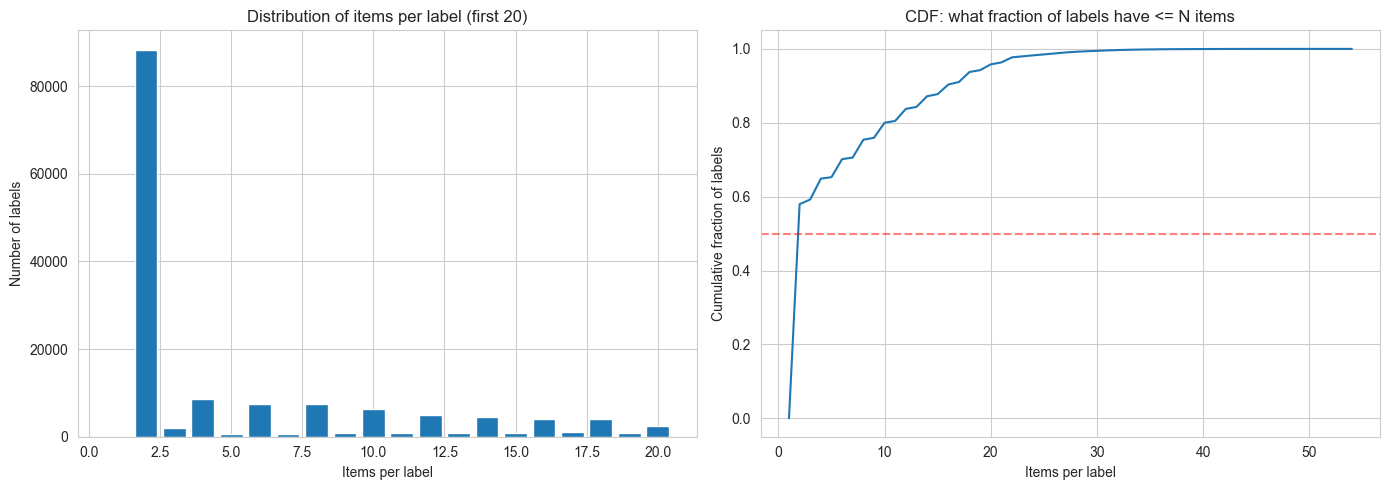


Labels with exactly 1 item (singletons): 8 (0.0%)
Labels with 2+ items (potential duplicates): 152362
Labels with 5+ items: 53519
Largest label group: 80 items


In [13]:
# How many labels have 1, 2, 3, ... items?
group_size_dist = label_counts.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
axes[0].bar(group_size_dist.index[:20], group_size_dist.values[:20])
axes[0].set_xlabel("Items per label")
axes[0].set_ylabel("Number of labels")
axes[0].set_title("Distribution of items per label (first 20)")

# Right: CDF
cdf = label_counts.value_counts().sort_index().cumsum() / len(label_counts)
axes[1].plot(cdf.index[:50], cdf.values[:50])
axes[1].set_xlabel("Items per label")
axes[1].set_ylabel("Cumulative fraction of labels")
axes[1].set_title("CDF: what fraction of labels have <= N items")
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nLabels with exactly 1 item (singletons): {group_size_dist.get(1, 0)} ({group_size_dist.get(1, 0)/len(label_counts)*100:.1f}%)")
print(f"Labels with 2+ items (potential duplicates): {(label_counts >= 2).sum()}")
print(f"Labels with 5+ items: {(label_counts >= 5).sum()}")
print(f"Largest label group: {label_counts.max()} items")

## 3. Geographic distribution

In [14]:
print("=== Train set ===")
print(train['geo'].value_counts())
print(f"\n=== Phase 1 set ===")
print(phase1['geo'].value_counts())

=== Train set ===
geo
sk    231187
cz     99079
bg     85837
hr     84752
ro     77356
lv     74146
hu     69219
si     62630
gr     51400
it     48091
lt     42310
ee      2135
pl        92
Name: count, dtype: int64

=== Phase 1 set ===
geo
sk    49894
cz    21381
hr    18423
bg    18158
ro    16748
lv    16111
hu    14964
si    13356
gr    10904
it    10415
lt     9041
ee      427
pl       13
Name: count, dtype: int64


In [15]:
# How many geos does a typical label span?
geos_per_label = train.groupby('label')['geo'].nunique()
print("Geos per label:")
print(geos_per_label.value_counts().sort_index())

print(f"\nLabels appearing in only 1 geo: {(geos_per_label == 1).sum()} ({(geos_per_label == 1).mean()*100:.1f}%)")
print(f"Labels spanning 2+ geos: {(geos_per_label >= 2).sum()} ({(geos_per_label >= 2).mean()*100:.1f}%)")

Geos per label:
geo
1     90861
2      8231
3      7895
4      8078
5      7152
6      5969
7      5508
8      5156
9      5693
10     3905
11     3666
12      256
Name: count, dtype: int64

Labels appearing in only 1 geo: 90861 (59.6%)
Labels spanning 2+ geos: 61509 (40.4%)


## 4. Text features — titles and descriptions

In [16]:
# Look at a few examples of the same product across geos
multi_geo_labels = geos_per_label[geos_per_label >= 3].index[:5]

for lbl in multi_geo_labels:
    subset = train[train['label'] == lbl][['title', 'geo', 'price']].head(6)
    print(f"\n{'='*80}")
    print(f"Label: {lbl} ({len(train[train['label'] == lbl])} items)")
    print(subset.to_string(index=False))


Label: 1 (14 items)
                                       title geo   price
Балеринки Clarks Freckle Ice 203529304 Кафяв  bg  120.00
                            Балеринки Clarks  bg  120.00
                             Baleríny Clarks  cz 1550.00
                             Baleríny Clarks  cz 1550.00
                             Baleríny Clarks  sk   62.95
                             Baleríny Clarks  sk   62.95

Label: 2 (12 items)
                                   title geo  price
Пантофи EMU Australia Jolie W10015 Черен  bg 159.00
                   Пантофи EMU Australia  bg 159.00
         Παντόφλες Σπιτιού EMU Australia  gr  79.90
         Παντόφλες Σπιτιού EMU Australia  gr  79.90
                    Papuče EMU Australia  sk  79.95
                    Papuče EMU Australia  sk  79.95

Label: 3 (17 items)
                                          title geo  price
Апрески EMU Australia Wallaby Mini K10103 Черен  bg  159.0
                          Апрески EMU Australia  bg  159

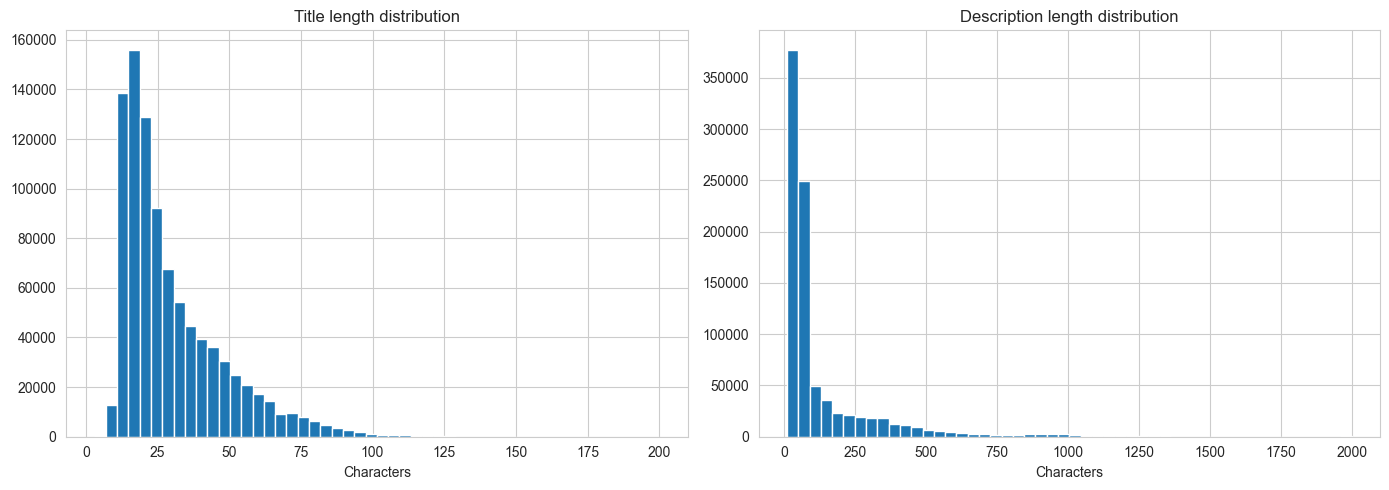

Missing titles: 0
Missing descriptions: 35473
Empty descriptions: 0


In [17]:
# Title length distribution
train['title_len'] = train['title'].astype(str).str.len()
train['desc_len'] = train['description'].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['title_len'].clip(upper=200).hist(bins=50, ax=axes[0])
axes[0].set_title("Title length distribution")
axes[0].set_xlabel("Characters")

train['desc_len'].clip(upper=2000).hist(bins=50, ax=axes[1])
axes[1].set_title("Description length distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print(f"Missing titles: {train['title'].isnull().sum()}")
print(f"Missing descriptions: {train['description'].isnull().sum()}")
print(f"Empty descriptions: {(train['description'].astype(str).str.strip() == '').sum()}")

## 5. Price analysis

In [18]:
print(train['price'].describe())
print(f"\nMissing prices: {train['price'].isnull().sum()}")
print(f"Zero prices: {(train['price'] == 0).sum()}")

count    9.282340e+05
mean     3.231983e+03
std      1.453706e+04
min      6.400000e-01
25%      3.799000e+01
50%      8.995000e+01
75%      3.499000e+02
max      1.013760e+06
Name: price, dtype: float64

Missing prices: 0
Zero prices: 0


In [19]:
# Price variation within the same label
# (are prices comparable across geos, or do we need currency normalization?)
price_stats = train.groupby('label')['price'].agg(['mean', 'std', 'min', 'max', 'count'])
price_stats = price_stats[price_stats['count'] >= 2]
price_stats['cv'] = price_stats['std'] / price_stats['mean']  # coefficient of variation

print("Price coefficient of variation within labels (for labels with 2+ items):")
print(price_stats['cv'].describe())

# Check if price is in local currency or normalized
print("\nMean price by geo:")
print(train.groupby('geo')['price'].mean().sort_values(ascending=False))

Price coefficient of variation within labels (for labels with 2+ items):
count    152362.000000
mean          0.733272
std           1.012493
min           0.000000
25%           0.000000
50%           0.000000
75%           1.579900
max           4.414245
Name: cv, dtype: float64

Mean price by geo:
geo
hu    38216.176772
cz     2511.347127
ro      548.693338
pl      451.487065
bg      201.488933
hr       97.857746
it       96.411186
lv       95.694388
si       94.017831
gr       92.487568
ee       85.566506
lt       78.553131
sk       51.794570
Name: price, dtype: float64


## 6. Structured features — departmentIds and colorTagIds

In [20]:
# What do these look like?
print("departmentIds examples:")
print(train['departmentIds'].head(10).tolist())
print(f"\ncolorTagIdsString examples:")
print(train['colorTagIdsString'].head(10).tolist())
print(f"\nMissing departmentIds: {train['departmentIds'].isnull().sum()}")
print(f"Missing colorTagIdsString: {train['colorTagIdsString'].isnull().sum()}")

departmentIds examples:
["['11']", "['11']", "['1']", "['1', '11']", "['11']", "['11']", "['1', '11']", "['1']", "['11']", "['11']"]

colorTagIdsString examples:
['230,232', '230,232', '230', '230', '230,232', '230,232', '230', '230,232', '230,232', '230']

Missing departmentIds: 0
Missing colorTagIdsString: 27834


In [21]:
# Are departmentIds consistent within a label?
dept_consistency = train.groupby('label')['departmentIds'].nunique()
print(f"Labels where all items share the same departmentIds: {(dept_consistency == 1).sum()} ({(dept_consistency == 1).mean()*100:.1f}%)")
print(f"Labels with varying departmentIds: {(dept_consistency > 1).sum()}")

Labels where all items share the same departmentIds: 140074 (91.9%)
Labels with varying departmentIds: 12296


## 7. Image column

In [22]:
# What's in the image column? URL? filename?
# brandEditionTagId — how useful is this?
print(f"Unique brandEditionTagIds: {train['brandEditionTagId'].nunique()}")
print(f"Missing: {train['brandEditionTagId'].isnull().sum()}")
print(f"\nExamples:")
print(train['brandEditionTagId'].head(10).tolist())

# Do items with the same label share brandEditionTagId?
brand_consistency = train.groupby('label')['brandEditionTagId'].nunique()
print(f"\nLabels where all items share same brandEditionTagId: {(brand_consistency == 1).sum()} ({(brand_consistency == 1).mean()*100:.1f}%)")

Unique brandEditionTagIds: 168
Missing: 925518

Examples:
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Labels where all items share same brandEditionTagId: 395 (0.3%)


## 8. Task 1 — the groups we need to classify

In [23]:
task1.head()

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761


In [24]:
print(f"Task 1 shape: {task1.shape}")
print(f"Columns: {task1.columns.tolist()}")
print(f"\nFirst row:")
print(task1.iloc[0])

Task 1 shape: (15000, 5)
Columns: ['item1', 'item2', 'item3', 'item4', 'item5']

First row:
item1     130622
item2     292253
item3     463442
item4     483968
item5    1253745
Name: 0, dtype: int64


In [25]:
# Figure out the structure — likely group_id + 5 item columns
# Look at what items are referenced
print("Column names and types:")
print(task1.dtypes)
print(f"\nNumber of groups: {len(task1)}")

Column names and types:
item1    int64
item2    int64
item3    int64
item4    int64
item5    int64
dtype: object

Number of groups: 15000


In [29]:
# Check: do task1 items come from phase1 or train?
# Get all item IDs from task1 (adjust column names after seeing the data)
item_cols = task1.columns.tolist()
print(f"Item columns: {item_cols}")

all_task_items = set()
for col in item_cols:
    all_task_items.update(task1[col].unique())

print(f"\nUnique items in task1: {len(all_task_items)}")

# Check overlap with train and phase1
# (adjust 'id' column name after seeing the actual data)
id_col = 'itemId'

train_ids = set(train[id_col].unique())

phase1_ids = set(phase1[id_col].unique()) if id_col in phase1.columns else set()

print(f"Task items in train: {len(all_task_items & train_ids)}")
print(f"Task items in phase1: {len(all_task_items & phase1_ids)}")
print(f"Task items in neither: {len(all_task_items - train_ids - phase1_ids)}")

Item columns: ['item1', 'item2', 'item3', 'item4', 'item5']

Unique items in task1: 75000
Task items in train: 0
Task items in phase1: 75000
Task items in neither: 0


## 9. Look at a few groups by eye

Let's manually inspect some groups to build intuition about what makes duplicates easy or hard.

In [27]:
# Join task1 items with their metadata
# Combine train + phase1 for full item lookup
all_items = pd.concat([train, phase1], ignore_index=True)

def show_group(group_idx):
    """Display all 5 items in a task1 group side by side."""
    row = task1.iloc[group_idx]
    print(f"Group index: {group_idx}")
    print(f"Group ID: {row.iloc[0]}")
    print("=" * 100)
    
    for i, col in enumerate(item_cols):
        item_id = row[col]
        item = all_items[all_items[id_col] == item_id]
        if len(item) == 0:
            print(f"  Item {i+1} ({item_id}): NOT FOUND")
            continue
        item = item.iloc[0]
        print(f"  Item {i+1} | id={item_id} | geo={item.get('geo', '?')} | price={item.get('price', '?')}")
        print(f"    title: {str(item.get('title', ''))[:100]}")
        if 'label' in item.index and pd.notna(item['label']):
            print(f"    label: {item['label']}")
        print()

# Show first 5 groups
for i in range(5):
    show_group(i)
    print()

Group index: 0
Group ID: 130622
  Item 1 | id=292253 | geo=hr | price=29.9
    title: Balerinke Sergio Bardi

  Item 2 | id=463442 | geo=hu | price=9990.0
    title: Calvin Klein Jeans gyerek sapka piros, IU0IU00440

  Item 3 | id=483968 | geo=hu | price=53880.0
    title: Bokacsizma Aldo

  Item 4 | id=1253745 | geo=sk | price=40.94
    title: Made Of Emotion Woman's Shorts M593


Group index: 1
Group ID: 82627
  Item 1 | id=388496 | geo=hu | price=37990.0
    title: Sportcipők New Balance

  Item 2 | id=553738 | geo=bg | price=31.0
    title: Мъжки колан Vans Deppster II Web VN0A31J1CHH1 Сив

  Item 3 | id=638400 | geo=cz | price=370.0
    title: Nazouváky ONLY Shoes

  Item 4 | id=884327 | geo=sk | price=21.5
    title: Trendyol Navy Blue A-Line Glittery Lined Chiffon Woven Dress


Group index: 2
Group ID: 46130
  Item 1 | id=333489 | geo=sk | price=18.84
    title: Rip Curl IMPACT REG BEANIE Mauve Winter Hat

  Item 2 | id=644448 | geo=bg | price=259.9
    title: Раница Tommy Hilfi

## 10. Quick sanity check — title overlap within groups

Simple heuristic: how similar are titles within each group? This tells us if title similarity alone could be a decent signal.

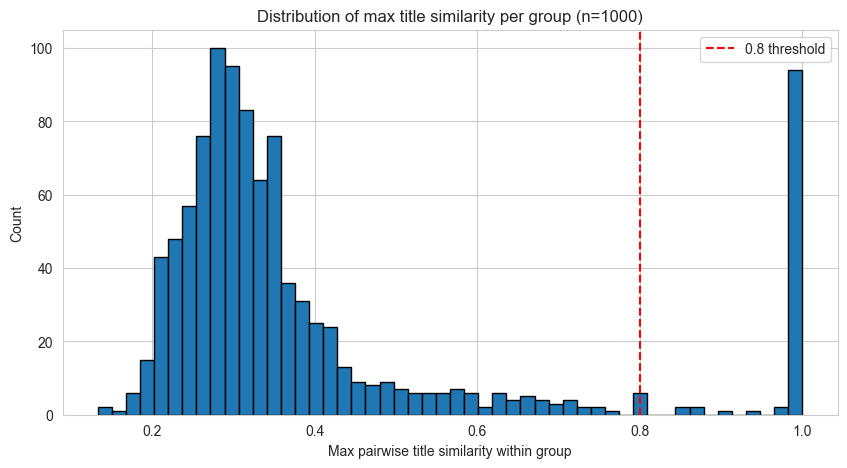

Groups with max title sim > 0.8: 104 (10.4%)
Groups with max title sim > 0.5: 176 (17.6%)


In [28]:
from difflib import SequenceMatcher

def title_similarity(t1, t2):
    """Simple character-level similarity ratio."""
    return SequenceMatcher(None, str(t1).lower(), str(t2).lower()).ratio()

# For each group, compute max pairwise title similarity
max_sims = []
sample_size = min(1000, len(task1))  # sample for speed

for idx in range(sample_size):
    row = task1.iloc[idx]
    titles = []
    for col in item_cols:
        item_id = row[col]
        item = all_items[all_items[id_col] == item_id]
        if len(item) > 0:
            titles.append(str(item.iloc[0].get('title', '')))
    
    if len(titles) >= 2:
        max_sim = max(title_similarity(t1, t2) for t1, t2 in combinations(titles, 2))
        max_sims.append(max_sim)

plt.figure(figsize=(10, 5))
plt.hist(max_sims, bins=50, edgecolor='black')
plt.xlabel("Max pairwise title similarity within group")
plt.ylabel("Count")
plt.title(f"Distribution of max title similarity per group (n={sample_size})")
plt.axvline(x=0.8, color='r', linestyle='--', label='0.8 threshold')
plt.legend()
plt.show()

print(f"Groups with max title sim > 0.8: {sum(1 for s in max_sims if s > 0.8)} ({sum(1 for s in max_sims if s > 0.8)/len(max_sims)*100:.1f}%)")
print(f"Groups with max title sim > 0.5: {sum(1 for s in max_sims if s > 0.5)} ({sum(1 for s in max_sims if s > 0.5)/len(max_sims)*100:.1f}%)")

## 11. Summary & next steps

After running this notebook, you should know:
- Column types and missing values
- How many items per product label (group size distribution)
- How products span across geos
- Whether prices are in local currency or normalized
- What the title/description text looks like across geos for the same product
- How task_1.csv is structured
- Whether simple title similarity is already a useful signal

**Next steps:**
1. Build a dumb baseline (TF-IDF on titles + threshold)
2. Extract multilingual text embeddings
3. Add structured feature similarities (price, department, color)
4. Train a group-level classifier